<h1> HW 1: Radar Imaging Part 1</h1>
In this lab assignment, we will implement a 3D mmWave Radar Imaging system. Before
starting the lab, please review the class lectures. We provide the data for students to work
on.

This lab consists of several tasks. The students are provided with some skeleton code for
loading the lab data in the correct format and plotting the output radar heatmaps/point
clouds for each task. The Jupyter notebook holds all of the relevant code blocks you will need to implement.

You must submit the lab file where you include the code, figures, and answer
the questions in each task.

The format of the mmWave radar data is as follows. The radar used has 1 transmitter and 4 receivers which is laid out linearly on the x axis (the transmitters are placed directly to the side of the receivers).
The radar data is collected by a 2D Synthetic Aperture Radar (SAR) with a size of 80 by 369 at one-wavelength by quarter-wavelength (i.e. the total size of the scanning area is 0.38 cm by 0.35 cm at 77 GHz). The 2D antenna array
is placed on the X-Z plane, as shown in Fig. 1. <i> NOTE: This is different than the coordinate system introduced in the lecture.</i> 

The mmWave radar has a center frequency of
77 GHz and it transmits Frequency Modulated Continuous Wave (FMCW) radar waveform
with 3.5991 GHz bandwidth (sweeps from 77 GHz with a slope of 70.295 MHz/us). 
The FMCW beat frequency signal (output of mixing reflected chirp with reference
chirp) is sampled 512 times at a sampling rate of 10,000 ksps. Therefore, the input mmWave radar data is a 3D matrix
with a of size 80 $\times$ 369 $\times$ 4 $\times$ 512. The first dimension is the first dimension is
horizontal (x axis) of the antenna array (in this case 80 steps by 4 receivers = 320), the second dimension is the vertical (z axis) of the
antenna array (369 in this case), and the third dimension is the number of data samples we have (512). 
The index of each antenna element can also be found in Fig. 1. We provide the x-position of the TX antenna (ant_pos) and  the x and z positions of the RX antenna elements (x_ant_pos and z_ant_pos). Where the transmitter will have the same z-position as each of the four Rx's it transmits to. 

Note on coding: You can change input/outputs from functions as you please as well as any plotting code, however, the final plotted image is what we will look at for grading. 
Additionally, we recommend that you 
comment your code to make it easier for partial credit to be awarded.

The data and details are available at https://drive.google.com/drive/folders/1nlwuhJWaXnyrXdVq2ced3E1wyYrFIIHH?usp=sharing.
A subset of what the results might look like are shown in example_outputs.pdf, however, this is of different data and not necessarily all of the plots we expect. These examples are simply to show an example of what you might expect. 

This lab is broken into three parts:
1. 1D Ranging using FMCW Radar Waveform
2. 2D Imaging using 1D Antenna Array
3. 3D Imaging using 2D Antenna Array

![title](imgs/coordinate_system.png)

<h3> 1. 1D Ranging using FMCW Radar Waveform </h3>

In this task, you will implement the radar signal processing for FMCW radar waveform for
unidirectional ranging.
The code for this task should be written below in the function: *uni_ranging()*. We provide you
the code to load the radar data in the right format in this file. As results, you need to include
the following in your report.

1. What is the range resolution of the FMCW radar waveform we provide?
2. Generate a figure of reflected signal power vs distance for the beat signal
on any one antenna element. Include this figure in the report.

Note: The ToF measured by our FMCW radar includes the propagation delay over the air and
inside the circuit. You need to compensate for the internal propagation in the circuit,
which is 0.15 meters in length to
get the ToF over the air. The internal propagation delay in time can be obtained by
dividing by speed of light.

Write your ranging function below.

In [1]:
######## Implement unidirectional ranging. #############
# TODO: add your code here
def uni_ranging(data, radar_params):
    '''Performs unidirectional ranging.
    
    Paramters: 
    - data: Raw SAR data (size: (adc_samples))

    Returns:
    - rdata: array of power at every range 
    - dist: array of distances from aperture 
    '''
    
    # Radar parameters
    sample_rate = radar_params["sample_rate"]
    num_samples = radar_params["num_samples"]
    slope = radar_params["slope"]
    lm = radar_params["lm"]
    num_z_stp = radar_params["num_z_stp"]
    num_tx = radar_params["num_tx"]
    num_rx = radar_params["num_rx"]
    adc_samples = radar_params["adc_samples"]

    # Range resolution
    c = 3e8
    T_s = num_samples / sample_rate
    B_s = slope * T_s
    d_min = c / (2 * B_s)

    # Compensate for internal propagation delay
    internal_propagation_length = 0.15 
        
    # Compute FFT
    spectrum = np.fft.fft(data)
    power_spectrum = np.abs(spectrum)
    
    # Generate array
    dist = np.linspace(0, num_samples * d_min, num_samples) - internal_propagation_length/2
    
    return power_spectrum, dist

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import utils

First we load the data and define the radar parameters below.

In [3]:
# TODO: Put the *path* to the data 
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/COM-304-Radars/homework/data/data_003_.mat'

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Run your code here.

In [4]:
power_spectrum, dist = uni_ranging(raw_data, radar_params)

Generate figure of the reflected signal power vs range of the reflector (distance between
the radar and the reflector) after compensating for the internal propagation delay in
the circuit. Plot this figure for the beat signal of any
one antenna element. Since selecting a single antenna out of the entire array may give different values based on the placement of the radar relative to the reflector,
you can play around with which antenna you select, as some will show clear peaks, and some will be noiser.

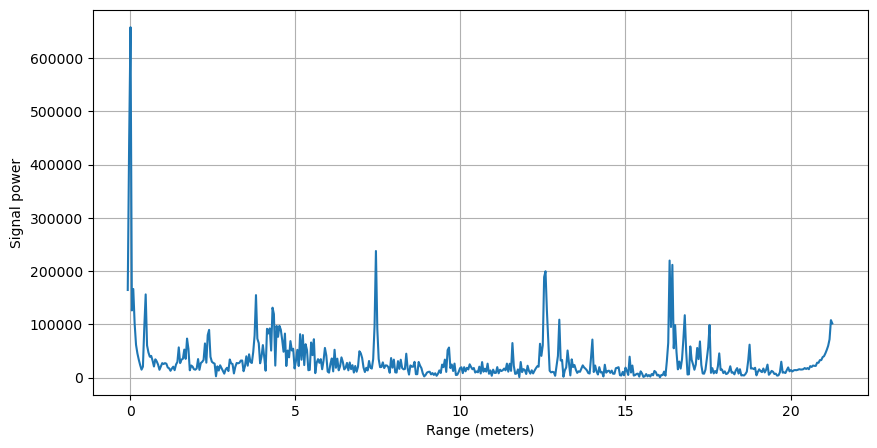

In [5]:
# TODO: Plot figures below
data_antenna = power_spectrum[100,100]

plt.figure(figsize=(10, 5))
plt.plot(dist, data_antenna)
plt.xlabel('Range (meters)')
plt.ylabel('Signal power')
plt.grid(True)
plt.show()

<h1> HW 1: Radar Imaging Part 2</h1>

<h3>2D Imaging using 1D Antenna Array </h3>

In this task, our goal is to implement Algorithm 1 (beamforming) taught in class for a
1D antenna array. You will generate the 2D radar heatmap (bird eye view) by estimating the reflected signal
power from azimuth angles $\phi$ between 60 and 130 degrees with a resolution of 1. The definition for $\phi$ can be found in Fig. 1 shown in task1.
The code for this task should be written in the function *beamform_1d*. We provide you the
code to load the radar data in the right format and to plot the 2D horizontal plane heatmap
in this file. 

As results, you need to include the following in your turned in file:
1. Include the 2D heatmap you generate. For the 1D antenna array signal, you can take
the beat signals from any one horizontal row of antenna elements in the 2D grid (aka select one z index to use).

Implement your 1D Beamforming algortihm.

In [27]:
# TODO: Implement the function
################# Change the values based on how much of the azimuth angles you want to see and the resolution ##################
# Define field of view in degrees that you want to process in theta 
def beamform_1d(beat_freq_data, phi_s, phi_e, phi_res, locs, radar_params):
    """
    Performs 1D beamforming along the azimuth (horizontal) dimension, this results in a bird eye view image.

    Paramters:
    - beat_freq_data: beat data AKA the range FFT (size: num_x_stps * num TX * num RX, num ADC samples)
    - phi_s: first angle that you want to start computing 
    - phi_e: last angle that you want to compute 
    - phi_res: resolution of the angles you want to compute
    - locs: antenna locations
    - radar_parms: radar_params if needed 

    Returns:
    - sph_pwr: beamformed result (size: num_phi x num adc samples)
    - phi: the array of the angles computed
    """

    # Radar parameters
    sample_rate = radar_params["sample_rate"]
    num_samples = radar_params["num_samples"]
    slope = radar_params["slope"]
    lm = radar_params["lm"]
    num_z_stp = radar_params["num_z_stp"]
    num_tx = radar_params["num_tx"]
    num_rx = radar_params["num_rx"]
    adc_samples = radar_params["adc_samples"]

    # Convert angles to radians
    phi = np.arange(phi_s, phi_e, phi_res) * np.pi / 180 
    num_phi = len(phi)

    # Initialize output
    sph_pwr = np.zeros((num_phi, adc_samples), dtype=np.complex64)
    
    for i, angle in enumerate(phi):
        
        # Compute phase shifts
        phase_shifts = slope * np.exp(-1j * 2 * np.pi * locs * np.cos(angle) / lm)
        
        # Apply phase shifts
        beamformed_signal = beat_freq_data * phase_shifts[:, np.newaxis]
        
        # Compute sph
        sph_pwr[i, :] = np.abs(np.sum(beamformed_signal, axis=0))
 
    return sph_pwr, phi 

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import time
import utils

Once again we will reload the data.

In [29]:
# TODO: Put the *path* to the project folder
data_path = '/Users/thomaskemper/Documents/EPFL/BA6/Communications project/COM-304-Radars/homework/data/data_003_.mat'

# loading data that is given
"""
    raw_data: is the raw radar data (after mixing) of size (num_x_stp x num_rx, num_z_stp, adc_samples)
    radar_params: is a dictionary with radar and position parameters: 'sample_rate', 'num_samples', 'slope', 'lm'(lambda), 'num_x_stp', 'num_z_stp', 'num_tx', 'num_rx', 'adc_samples' 
"""
radar_params, raw_data = utils.load_raw_data(data_path)

Here we define the antenna spacing. Take a look and make sure to understand how each antenna is placed.

In [30]:
ant_pos = utils.get_ant_pos_1d(radar_params['num_x_stp'], radar_params['num_rx']).flatten()

Process the raw data so we have the beat frequency (see lectures). Additionally, you only need to run this on *one* vertical (z) location. So pick one.

In [31]:
# TODO: Process Raw Data for Beamforming 
beat_freq = np.fft.fft(raw_data)

Define the angles to calculate and run your algorthim below.

In [32]:
# define the azimuth angles (horizontal FOV) that we want to look at 
phi_s, phi_e = 60, 130
phi_res = 1
# Run your algorithm here
bf_output, phi = beamform_1d(beat_freq[:,100,:], phi_s,phi_e,phi_res,ant_pos,radar_params)

Here is code for plotting the heatmap. If you are not seeing colorful 2D heatmaps as expected, tune the variables *vmin* and *vmax* as those determine the colormap.

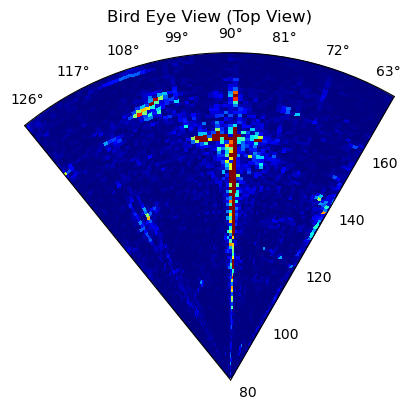

In [33]:
# Plot the output from 1D Beamforming (You can change this as you see fit)
fig = plt.figure()
r_idxs = np.arange(80,180) 
to_plot = abs(bf_output[:,r_idxs])
to_plot = to_plot
to_plot = to_plot/np.max(np.reshape(to_plot,(1,-1))) 
to_plot = to_plot[:,::-1]**2

ax0 = fig.add_subplot(111, projection='polar')
utils.plot_2d_heatmap(ax0, to_plot, phi, r_idxs, vmin=0, vmax=0.1)
ax0.title.set_text('Bird Eye View (Top View)')
ax0.set_aspect('equal','box')